In [1]:
# %%
import sys, os
import numpy as np
import matplotlib.pyplot as plt
Directory = r'D:\Ring_MIT_Sid_chip\scripts\del_n_comparison'
os.chdir(Directory)
pwd = os.getcwd()
print(pwd)


D:\Ring_MIT_Sid_chip\scripts\del_n_comparison


In [2]:

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  
# %matplotlib qt
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")

LumFileName = "Ring30um_del_n.lms" # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()

# %%
f.switchtolayout()

#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------

LambdaStart    = 1530E-9
LambdaStop     = 1570E-9

Width          = 1000E-9
Height         = 800E-9
Radius         = 30E-6
Gap            = 400E-9
Length         = 4 * Radius
# Material       = "Si3N4 (Silicon Nitride) - Luke"
CouplingLength = 0.0E-6
Index          = 2.0+0.0005
print(f"Index: {Index}")
BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 500E-12
# FrequencyPoints    = 2*10000; #for monitors 
FrequencyPoints    = int(2000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Starting new Lumerical MODE session...
Index: 2.0005
Frequency Points: 80000


1
[0.]
Minimum radius: 1.00 µm
Maximum radius: 1.00 µm


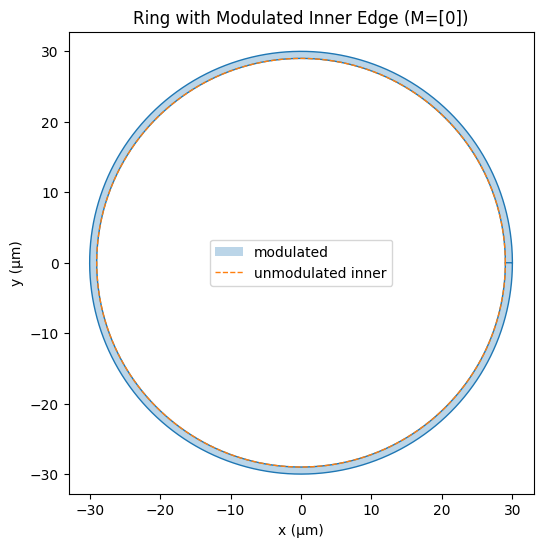

In [3]:

# ring hyperparameters
M = [0]  # Mode numbers (use non-zero for modulation)
A = np.full(len(M), 0e-9)  # Amplitude of modulation
print(len(A))
print(A)
# Ensure minimum points even if M[0] is small
Npoints = max(5000, 300*M[0])  # Number of points for smoothness

def generate_inner_modulated_ring(Radius=4e-6,
                                width=700e-9,
                                A=300e-9,
                                M=50,
                                Npoints=1000):
    theta         = np.linspace(0, 2*np.pi, Npoints)
    R_inner_base  = Radius - width
    R_outer_base  = Radius 

    # ensure A_list, M_list
    A_list = np.atleast_1d(A)
    M_list = np.atleast_1d(M)

    # sum of cosines
    modulation = np.zeros_like(theta)
    for Ai, Mi in zip(A_list, M_list):
        if Mi == 0:
            # No modulation for M=0
            modulation += Ai
        else:
            # Normalized modulation
            # modulation += Ai * (np.cos(Mi * theta ) + 1) / max((np.cos(Mi * theta)))
            modulation += Ai * (np.cos(2*Mi * theta ) +1)

    R_inner       = R_inner_base - modulation
    R_outer_const = R_outer_base
    
    min_radius = np.min(R_outer_const-R_inner)
    print(f"Minimum radius: {min_radius*1e6:.2f} µm")
    
    max_radius = np.max(R_outer_const-R_inner)
    print(f"Maximum radius: {max_radius*1e6:.2f} µm")

    x_inner = R_inner * np.cos(theta)
    y_inner = R_inner * np.sin(theta)
    x_outer = R_outer_const * np.cos(theta[::-1])
    y_outer = R_outer_const * np.sin(theta[::-1])

    x_poly = np.concatenate([x_inner, x_outer])
    y_poly = np.concatenate([y_inner, y_outer])
    return x_poly, y_poly

x_poly, y_poly = generate_inner_modulated_ring(Radius=Radius ,
                                            width=Width, A = A, M=M, Npoints=Npoints)
# compute unmodulated inner ring
theta_base   = np.linspace(0, 2*np.pi, Npoints)
R_inner_base = Radius - Width  
x_base       = R_inner_base * np.cos(theta_base)
y_base       = R_inner_base * np.sin(theta_base)

# visualize
plt.figure(figsize=(6,6))
plt.fill(x_poly*1e6, y_poly*1e6, alpha=0.3, label='modulated')
plt.plot(x_poly*1e6, y_poly*1e6, '-', linewidth=1)
plt.plot(x_base*1e6, y_base*1e6, '--', linewidth=1, label='unmodulated inner')
plt.axis('equal')
plt.gcf().set_dpi(100)
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title(f'Ring with Modulated Inner Edge (M={M})')
plt.legend()
plt.show()


In [4]:

# %%
#------------------------------------------------------------
# STRUCTURE GROUP : Ring 
#------------------------------------------------------------

group_name = "Ring Resonator Group"
f.addstructuregroup()
f.set("name", group_name)
f.set("construction group", 1)
f.set("x",0)
f.set("y",0)
f.set("z",0)

# ADD USER PROPERTIES (keep original ones only)
f.adduserprop("Width",          2, Width)
f.adduserprop("Height",         2, Height)
f.adduserprop("Radius",         2, Radius)
f.adduserprop("Gap",            2, Gap)
f.adduserprop("Length",         2, Length)
# f.adduserprop("Material",       5, Material)
f.adduserprop("Index",          0, Index)
f.adduserprop("CouplingLength", 2, CouplingLength)

# Convert vertices to Lumerical matrix format
vertices_str = "["
for i in range(len(x_poly)):
    vertices_str += f"{x_poly[i]}, {y_poly[i]};"
vertices_str = vertices_str.rstrip(';') + "]"

#------------------------------------------------------------
# GEOMETRY SETUP SCRIPT
#------------------------------------------------------------

setup_script = f"""
# Base waveguides
addrect;
set('name','WG1');
set('x', 0);
set('x span', Length);
set('y span', Width);
set('y', Radius + Gap + Width/2);
copy(0, -2 * (Radius + Gap + Width/2), 0);

# Modulated Ring using polygon vertices
addpoly;
set('name', 'modulated_ring');
set('vertices', {vertices_str});

# Assign materials & finalize structure
selectall;
# set('material', Material);
# if (Material == '<Object defined dielectric>') {{
#     set('index', Index);
# }}
set('index', Index);
set('z min', 0);
set('z max', Height);
"""

f.set("script", setup_script)

# %%


#------------------------------------------------------------
# EigenMode Solver 
#------------------------------------------------------------

# f.addfde()
# f.set("x", Radius+CouplingLength/2)  # Aligned with the right ring
# f.set("x span", 2 * Width)
# f.set("y", 0)  # Centered in Y
# f.set("z", Height / 2)  # Centered in Z
# f.set("y span", 2 * Width)
# f.set("solver type", "2D Y Normal")
# f.set("wavelength", (LambdaStart + LambdaStop) / 2)
# f.set("background material", BackgroundMaterial)

#------------------------------------------------------------
# VarFDTD
#------------------------------------------------------------

f.addvarfdtd()
f.set("simulation time", SimulationTime) 
f.set("x0", Width/2-Radius-CouplingLength/2)              # mode position (that green arrow)
f.set("y0",0)
# f.set("y0", Radius + Gap + Width)
f.set("x", 0)                    # Centered in X
f.set("x span", 2.5 * Radius + CouplingLength/2)    # Cover full structure
f.set("y", 0)                    # Centered in Y
f.set("y span", 2.5 * (Radius + Gap + Width))  # Cover full waveguide & ring
f.set("z", Height / 2)           # Centered in Z
f.set("z span", 8*Height)        # Cover height of the structure
f.set("background material",BackgroundMaterial)
f.set("set simulation bandwidth",1)
f.set("bandwidth",'broadband')
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("auto shutoff min",1E-5)

# Boundary Conditions
f.set("x min bc", "PML")
f.set("x max bc", "PML")
f.set("y min bc", "PML")
f.set("y max bc", "PML")
f.set("z min bc", "PML")
f.set("z max bc", "PML")

# TEST POINT POSITIONS (Blue Arrows) - On the Arc
theta = [45, 135, 225, 315]   # Angles for test points (degrees)
test_points = np.zeros((2, 4))  # Creates a 2-row, 4-column matrix for (x, y) coordinates

for i in range(4):
    angle_rad = theta[i] * np.pi / 180  # Convert degrees to radians
    test_points[0, i] = Radius * np.cos(angle_rad)  # x-coordinate
    test_points[1, i] = Radius * np.sin(angle_rad)  # y-coordinate

f.set("test points", test_points)

#------------------------------------------------------------
# Source
#------------------------------------------------------------

# f.addmodesource()
# f.set("name", "ModeSource")
# f.set("x", -Radius-CouplingLength/2)
# f.set("y", Radius + Gap + Width/2)
# f.set("y span", 2 * Width)
# f.set("use relative coordinates", 1)
# f.set("injection axis", "x-axis")
# f.set("direction", "Forward")
# f.set("amplitude", 1.0)
# f.set("phase", 0)
# f.set("mode selection", "fundamental mode")
# f.set("set wavelength", 1)
# f.set("wavelength start", LambdaStart)
# f.set("wavelength stop", LambdaStop)

f.addplane()
f.set("name", "PlaneWaveSource")
f.set("injection axis", "x-axis")
f.set("x", -Radius-CouplingLength/2)
f.set("y", Radius + Gap + Width/2)
f.set("y span", Width)
f.set("use relative coordinates", 1)
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)

# %%

#------------------------------------------------------------
# Monitors 
#------------------------------------------------------------

# THROUGH PORT
f.adddftmonitor()
f.set("name", "Through")
f.set("monitor type", "Linear Y")
f.set("x", Radius+CouplingLength/2)
f.set("y", Radius + Gap + Width/2)
f.set("y span", 2 * Width)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

# DROP PORT
f.adddftmonitor()
f.set("name", "Drop")
f.set("monitor type", "Linear Y")
f.set("x", -Radius-CouplingLength/2)
f.set("y", -(Radius + Gap + Width/2))
f.set("y span", 2 * Width)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

# # Reflection PORT
# f.adddftmonitor()
# f.set("name", "R")
# f.set("monitor type", "Linear Y")
# f.set("x", -Radius-CouplingLength/2-1*LambdaStart)
# f.set("y", Radius + Gap + Width)
# f.set("y span", 2 * Width)
# f.set("z", Height / 2)  # Centered in Z
# f.set("override global monitor settings", 1)
# f.set("use source limits", 1)
# f.set("frequency points", FrequencyPoints)

# # Field Monitor PORT
# f.adddftmonitor()
# f.set("name", "Field Monitor")
# f.set("monitor type", "2D Z-normal")
# f.set("x", 0)                    # Centered in X
# f.set("x span", 2.4 * Radius + CouplingLength/2)    # Cover full structure
# f.set("y", 0)                    # Centered in Y
# f.set("y span", 2.3 * (Radius + Gap + Width))  # Cover full waveguide & ring
# f.set("z", Height / 2)  # Centered in Z
# f.set("override global monitor settings", 1)
# f.set('use wavelength spacing',1)
# f.set('wavelength center', 0.75E-6)  # Center wavelength
# f.set('wavelength span', 0.008E-6) 
# f.set("frequency points", 4)




In [5]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------
f.run()

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_Ring30um_del_n_n2.0005_Tx.txt


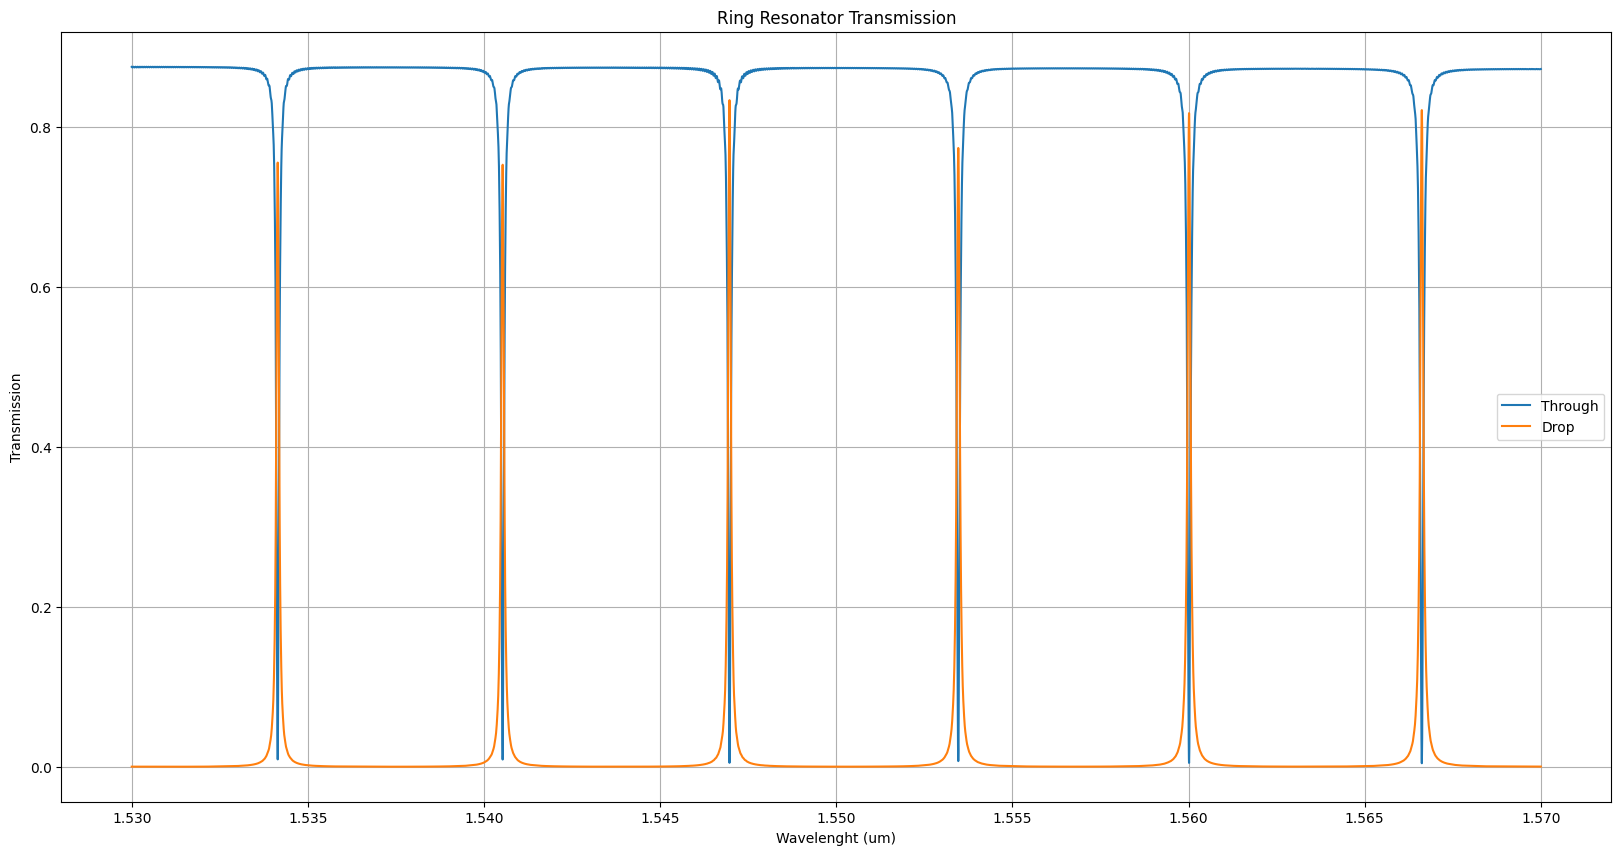

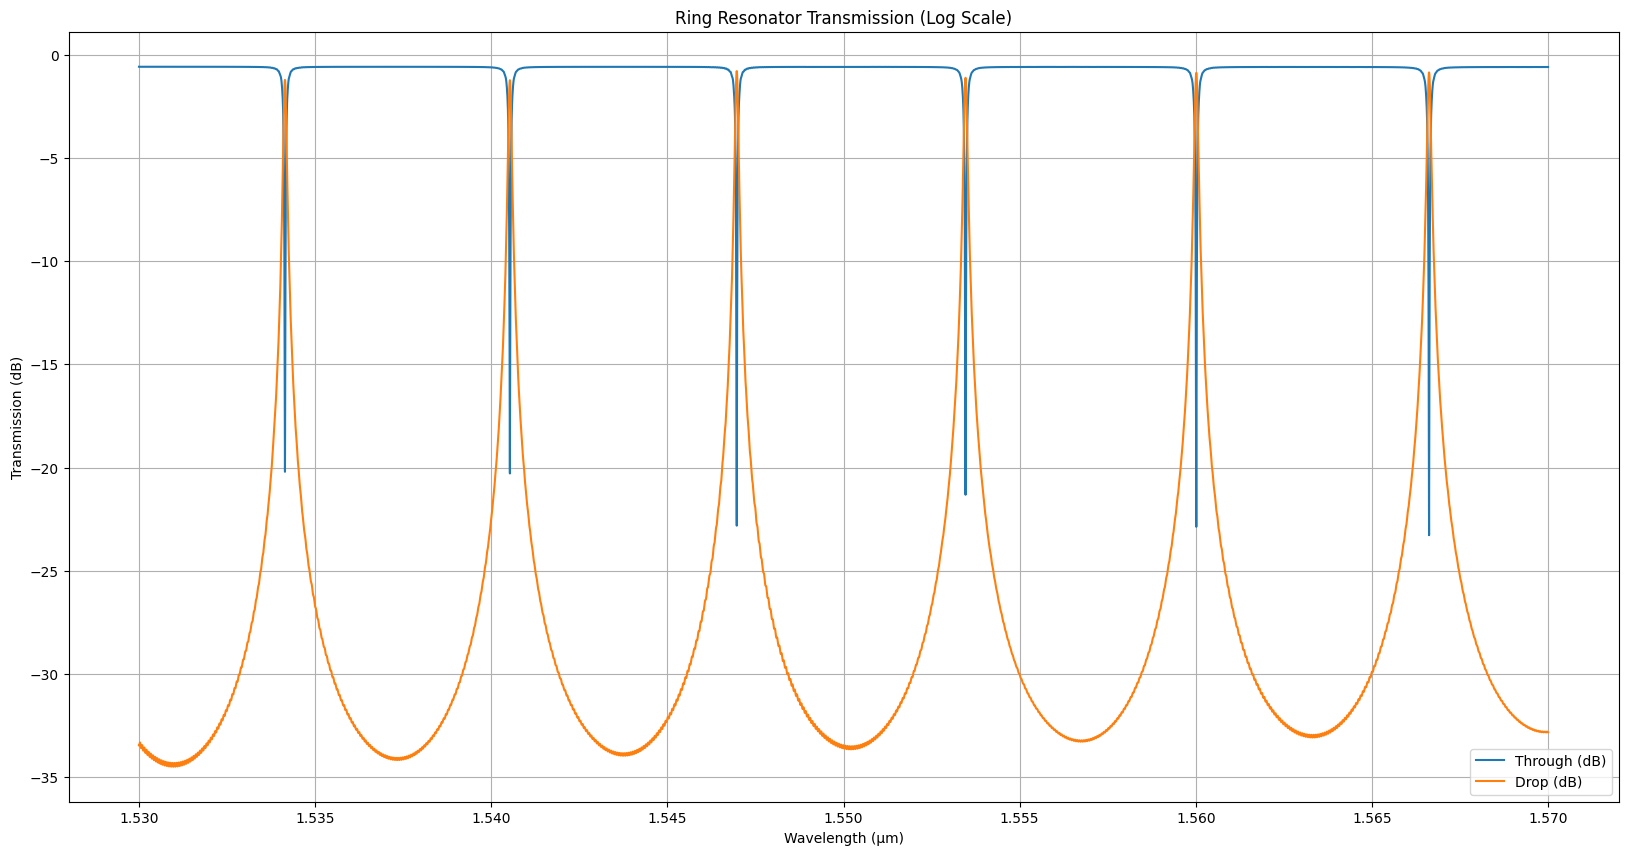

In [6]:
#------------------------------------------------------------
# Save Data
#------------------------------------------------------------

# GET RELEVENT RESULTS
T_through = f.getresult("Through","T")
T_drop    = f.getresult("Drop","T")

Transmission_through = T_through['T']
Transmission_drop    = -T_drop['T']
# Refelction = f.getresult("R","T")['T']
Wavelenghth          = T_drop['lambda']

plt.figure(figsize=(20,10))
plt.plot(Wavelenghth*1E6,Transmission_through, label='Through')
plt.plot(Wavelenghth*1E6,Transmission_drop, label='Drop')
plt.xlabel("Wavelenght (um)")
plt.ylabel("Transmission")
plt.title("Ring Resonator Transmission")
plt.legend()
plt.grid()

plt.figure(figsize=(20,10))
plt.plot(Wavelenghth*1E6, 10*np.log10(Transmission_through), label='Through (dB)')
plt.plot(Wavelenghth*1E6, 10*np.log10(Transmission_drop),    label='Drop (dB)')
plt.xlabel("Wavelength (µm)")
plt.ylabel("Transmission (dB)")
plt.title("Ring Resonator Transmission (Log Scale)")
plt.legend()
plt.grid()

#save data
from pathlib import Path

filename = Path(r'D:\Ring_MIT_Sid_chip\results_data')/f"Data_{LumFileName.removesuffix('.lms')}_n{Index}_Tx.txt"
data = np.column_stack([Wavelenghth*1E6, Transmission_through, Transmission_drop])
np.savetxt(filename, data, header="Wavelength(um) Transmission_Through Transmission_Drop",)

print(f"Data saved to {filename}")

In [7]:
np.savetxt?

Signature:      
np.savetxt(
    fname,
    X,
    fmt='%.18e',
    delimiter=' ',
    newline='\n',
    header='',
    footer='',
    comments='# ',
    encoding=None,
)
Call signature:  np.savetxt(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function savetxt at 0x0000028250810720>
File:            c:\users\smmit\miniconda3\envs\dl_ml_env\lib\site-packages\numpy\lib\_npyio_impl.py
Docstring:      
Save an array to a text file.

Parameters
----------
fname : filename, file handle or pathlib.Path
    If the filename ends in ``.gz``, the file is automatically saved in
    compressed gzip format.  `loadtxt` understands gzipped files
    transparently.
X : 1D or 2D array_like
    Data to be saved to a text file.
fmt : str or sequence of strs, optional
    A single format (%10.5f), a sequence of formats, or a
    multi-format string, e.g. 'Iteration %d -- %10.5f', in which
    case `delimiter` is ignored. For complex `X`, the legal options
    for `fmt` are:
